# EDA — M5 retail demand

Explores seasonality and baseline forecast quality on the project's core
schema: one row per (date, store_id, item_id, sales).

This notebook runs standalone on a small **locally-generated synthetic
sample** (no GCP/BigQuery credentials needed), so it's a real, runnable
artifact rather than a stub. Once `infra/terraform` is applied and
`dbt run` has built `fct_sales`, swap the sample-generation cell below for a
query against that mart — everything downstream (the plots, the baseline
comparison) is schema-compatible and doesn't need to change.

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from retail_demand.models.baseline import (
    naive_forecast,
    score_forecast,
    seasonal_naive_forecast,
)

pd.options.display.float_format = "{:.2f}".format

## Sample data

A small multi-item, multi-store sample with weekly seasonality, a mild
upward trend, and noise — stands in for a slice of `fct_sales` until real
GCP credentials are configured (see `data/README.md`).

In [2]:
rng = np.random.default_rng(7)

start = dt.date(2024, 1, 1)
n_days = 120
series_keys = [
    ("CA_1", "FOODS_1_001"),
    ("CA_1", "FOODS_1_002"),
    ("CA_2", "HOBBIES_1_010"),
]
weekday_multiplier = np.array([1.0, 0.9, 0.9, 1.0, 1.1, 1.4, 1.3])  # Mon..Sun, weekend bump

rows = []
for store_id, item_id in series_keys:
    base = rng.uniform(8, 20)
    trend = rng.uniform(0.0, 0.03)
    for i in range(n_days):
        date = start + dt.timedelta(days=i)
        seasonal = base * weekday_multiplier[date.weekday()]
        noise = rng.normal(loc=1.0, scale=0.15)
        sales = max(0, round(seasonal * (1 + trend * i) * noise))
        rows.append(
            {"date": pd.Timestamp(date), "store_id": store_id, "item_id": item_id, "sales": sales}
        )

sample = pd.DataFrame(rows)
sample.head()

,date,store_id,item_id,sales
0,2024-01-01,CA_1,FOODS_1_001,15
1,2024-01-02,CA_1,FOODS_1_001,12
2,2024-01-03,CA_1,FOODS_1_001,14
3,2024-01-04,CA_1,FOODS_1_001,14
4,2024-01-05,CA_1,FOODS_1_001,19


## Sales over time, by series

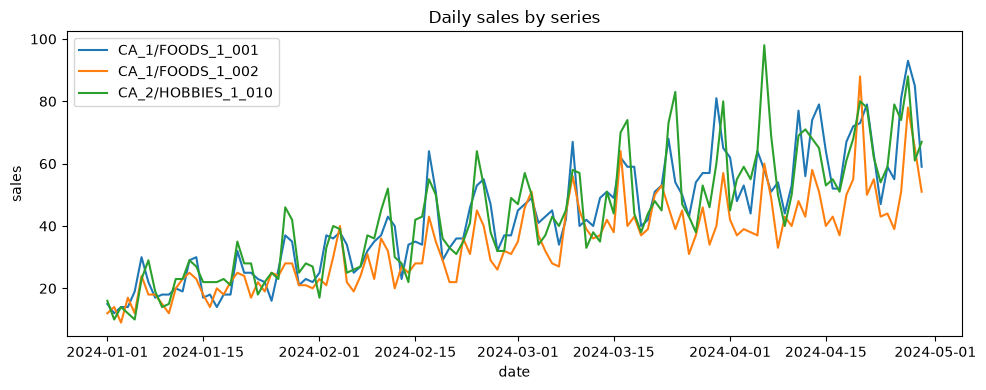

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
for (store_id, item_id), series in sample.groupby(["store_id", "item_id"]):
    series = series.sort_values("date")
    ax.plot(series["date"], series["sales"], label=f"{store_id}/{item_id}")
ax.set_title("Daily sales by series")
ax.set_xlabel("date")
ax.set_ylabel("sales")
ax.legend()
fig.tight_layout()

## Weekday seasonality

Confirms the weekend bump baked into the sample generator — on real data
this is where you'd check whether weekly seasonality assumptions (used by
the seasonal-naive baseline and the synthetic daily-feed generator) hold.

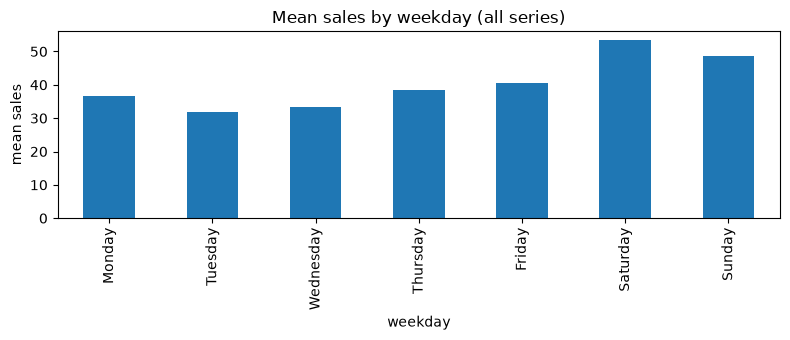

In [4]:
by_weekday = (
    sample.assign(weekday=sample["date"].dt.day_name()).groupby("weekday")["sales"].mean()
)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_weekday = by_weekday.reindex(weekday_order)

fig, ax = plt.subplots(figsize=(8, 3.5))
by_weekday.plot.bar(ax=ax)
ax.set_title("Mean sales by weekday (all series)")
ax.set_ylabel("mean sales")
fig.tight_layout()

## Baseline comparison: naive vs. seasonal-naive

Hold out the last 14 days as a test window, forecast them from the
remaining history with both baselines from
`src/retail_demand/models/baseline.py`, and score with MAPE/RMSE. Whichever
wins here is the bar Phase 3's LightGBM model needs to clear.

In [5]:
horizon = 14
cutoff = sample["date"].max() - pd.Timedelta(days=horizon)

train = sample[sample["date"] <= cutoff]
test = sample[sample["date"] > cutoff]

naive_pred = naive_forecast(train, horizon=horizon)
seasonal_pred = seasonal_naive_forecast(train, horizon=horizon, season_length=7)

results = pd.DataFrame(
    [
        {"model": "naive", **score_forecast(test, naive_pred)},
        {"model": "seasonal_naive", **score_forecast(test, seasonal_pred)},
    ]
).set_index("model")
results

,mape,rmse,n
model,,,
naive,0.20,17.14,42
seasonal_naive,0.14,11.80,42


On data with real weekly seasonality (as generated here), seasonal-naive
should beat plain naive on both MAPE and RMSE — if it doesn't on real
`fct_sales` data, that's a sign the series is noisier or less seasonal than
assumed, worth knowing before jumping to Phase 3's LightGBM model.